# Regularization in Machine Learning

Regularization reduces **overfitting** by adding a penalty to large model weights : preferring simpler models even if they fit training data slightly worse.

| Method | Penalty | Effect |
|--------|---------|--------|
| Ridge | $\lambda \|w\|_2^2$ | Shrinks all weights |
| Lasso | $\lambda \|w\|_1$ | Shrinks + zeroes weights |
| Elastic Net | $\lambda(\alpha\|w\|_1 + (1-\alpha)\|w\|_2^2)$ | Combines both |

In [36]:
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

## 1. Overfitting Demo

A degree-1 polynomial **underfits**, degree-3 fits well, degree-15 **overfits**.

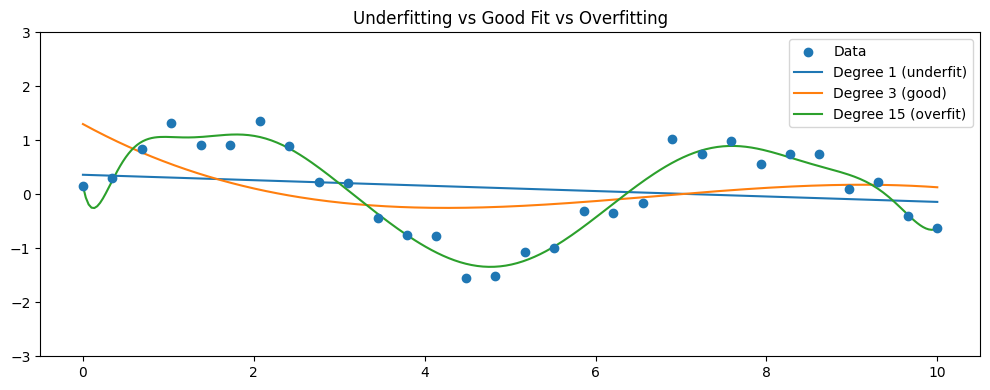

In [37]:
np.random.seed(42)
X_demo = np.linspace(0, 10, 30)
y_demo = np.sin(X_demo) + np.random.normal(scale=0.3, size=len(X_demo))

X_plot  = np.linspace(0, 10, 300)
degrees = [1, 3, 15]
labels  = ['Degree 1 (underfit)', 'Degree 3 (good)', 'Degree 15 (overfit)']

plt.figure(figsize=(10, 4))
plt.scatter(X_demo, y_demo, label='Data', zorder=3)
for deg, lbl in zip(degrees, labels):
    coeff = np.polyfit(X_demo, y_demo, deg)
    plt.plot(X_plot, np.polyval(coeff, X_plot), label=lbl)
plt.ylim(-3, 3)
plt.title('Underfitting vs Good Fit vs Overfitting')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Linear Regression Baseline

**Closed-form (Normal Equation):**
$$w = (X^\top X)^{-1} X^\top y$$

**Gradient Descent update:**
$$w := w - \alpha \cdot \frac{2}{n} X^\top(Xw - y)$$

In [38]:
def add_bias(X):
    """Add intercept column: X -> [1, X]"""
    return np.c_[np.ones(X.shape[0]), X]

def predict(X, w):
    return add_bias(X) @ w

def linear_regression_closed_form(X, y):
    """
    Normal equation: w = (XtX)^-1 Xty
    """
    Xb = add_bias(X)
    return np.linalg.inv(Xb.T @ Xb) @ Xb.T @ y

def linear_regression_gd(X, y, lr=0.01, n_iter=1000):
    """
    Gradient: dw = (2/n) Xt(Xw - y)
    Update:   w  = w - lr * dw
    """
    Xb = add_bias(X)
    np.random.seed(42)
    w = np.random.randn(Xb.shape[1])
    n = len(y)
    history = []
    for _ in range(n_iter):
        error = Xb @ w - y
        y_pred = Xb @ w
        error = y_pred - y
        w    -= lr * (2/n) * Xb.T @ error
        history.append(np.mean(error**2))
    return w, history

Closed-form weights (b, w): [2.2 0.6]
GD weights        (b, w): [2.15292185 0.61303989]


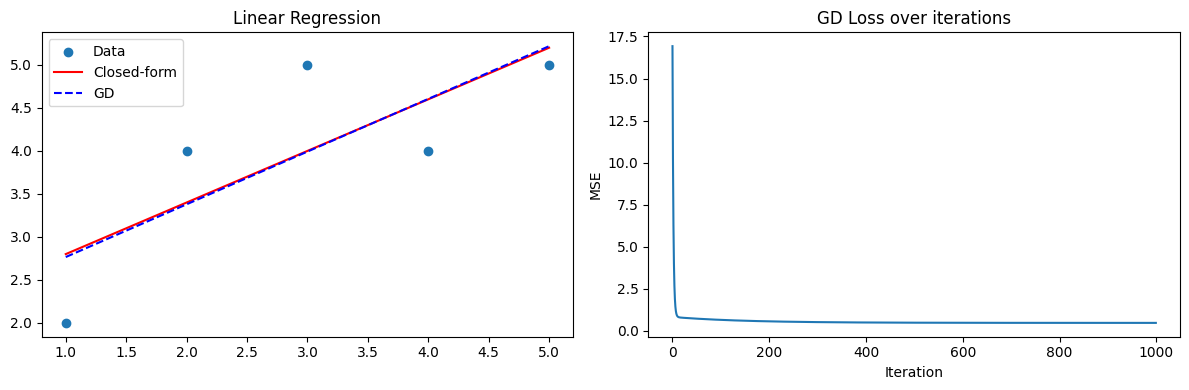

In [39]:
# Simple 1-D dataset used throughout
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 5, 4, 5], dtype=float)

w_cf = linear_regression_closed_form(X, y)
w_gd, loss_history = linear_regression_gd(X, y)

print('Closed-form weights (b, w):', w_cf)
print('GD weights        (b, w):', w_gd)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X, y, label='Data')
axes[0].plot(X, predict(X, w_cf), label='Closed-form', color='red')
axes[0].plot(X, predict(X, w_gd), label='GD', color='blue', linestyle='--')
axes[0].set_title('Linear Regression')
axes[0].legend()

axes[1].plot(loss_history)
axes[1].set_title('GD Loss over iterations')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('MSE')

plt.tight_layout()
plt.show()

### Observations : Simple 1D Linear Regression

- Both **closed-form** and **gradient descent** give very similar weights.
- GD approximates the closed-form solution, with tiny differences due to initialization and finite iterations.
- The **loss plot** shows that GD converges smoothly to a minimum.
- This demonstrates that **gradient descent works well even for small datasets**, though closed-form is exact and faster here.

## 3. Ridge Regression (L2)

$$
L(w) = \|y - Xw\|^2 + \lambda \|w\|_2^2
$$

**Closed-form:**

$$
w = (X^\top X + \lambda I)^{-1} X^\top y
$$

*(bias excluded from penalty)*

**GD gradient:**

$$
\nabla w = 2X^\top(Xw - y) + 2\lambda w
$$


In [40]:
def ridge_closed_form(X, y, lambda_):
    """
    Closed-form: w = (XtX + lambdaI)^-1 Xty
    I[0,0] = 0 -> bias not penalized.
    """
    Xb = add_bias(X)
    I = np.eye(Xb.shape[1])
    I[0, 0] = 0
    return np.linalg.inv(Xb.T @ Xb + lambda_ * I) @ Xb.T @ y

def ridge_gd(X, y, lambda_=1.0, lr=0.01, n_iter=1000):
    """
    Gradient: 2 * Xt(Xw-y) + 2*lambda*w  (bias not regularized)
    """
    Xb = add_bias(X)
    np.random.seed(42)
    w = np.random.randn(Xb.shape[1])
    n = len(y)
    history = []
    for _ in range(n_iter):
        error  = Xb @ w - y
        grad   = 2 * Xb.T @ error
        reg    = 2 * lambda_ * w.copy()
        reg[0] = 0
        w     -= lr * (grad + reg)
        history.append(np.mean(error**2))
    return w, history

Ridge closed-form: [2.36363636 0.54545455]
Ridge GD:          [2.36363635 0.54545455]


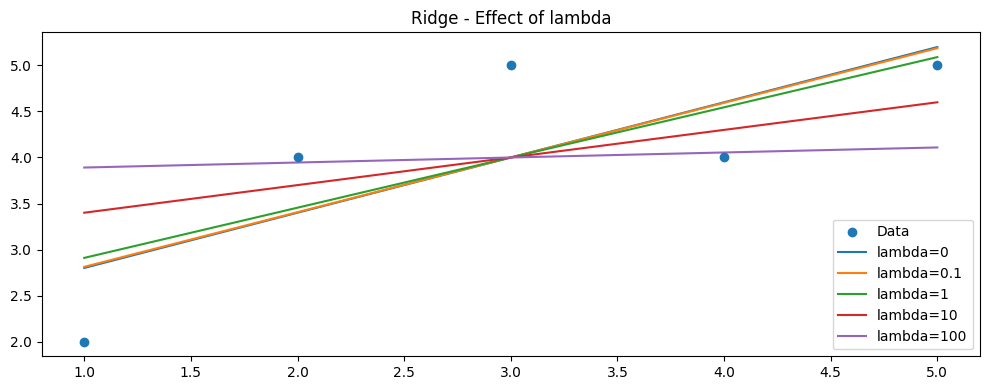

In [41]:
w_ridge_cf, _ = ridge_closed_form(X, y, 1.0), None
w_ridge_cf    = ridge_closed_form(X, y, 1.0)
w_ridge_gd, _ = ridge_gd(X, y, lambda_=1.0)

print('Ridge closed-form:', w_ridge_cf)
print('Ridge GD:         ', w_ridge_gd)

# Effect of lambda
Xb = add_bias(X)
lambdas = [0, 0.1, 1, 10, 100]

plt.figure(figsize=(10, 4))
plt.scatter(X, y, label='Data', zorder=3)
for lam in lambdas:
    w = ridge_closed_form(X, y, lam)
    plt.plot(X, Xb @ w, label=f'lambda={lam}')
plt.title('Ridge - Effect of lambda')
plt.legend()
plt.tight_layout()
plt.show()

### Observations : Ridge Regression

- **Ridge closed-form** and **GD** give slightly different weights due to GD approximation and learning dynamics.
- Increasing **lambda** shrinks the slope (w) toward zero while slightly adjusting the bias.
- Small lambda values → solution close to standard linear regression.
- Large lambda → stronger regularization, reduces model complexity and prevents overfitting.

## 4. Lasso Regression (L1)
With L2, we had a smooth, round constraint, which makes optimization nice and clean. But L1 changes the shape and that change in geometry is exactly why we lose the closed-form solution.

![Alt text](https://miro.medium.com/v2/resize:fit:640/format:webp/0*_pKBpbrub8v6np5x.png)

The geometry forces zeros. The L1 constraint has corners that sit exactly on the axes. When the loss ellipse shrinks to touch the diamond, it almost always hits a corner, meaning one weight is exactly zero. Ridge has no corners.


![Alt text](https://i.sstatic.net/SsjCl.png)
L1 regularization uses the absolute value of the weights. The problem is that the absolute value function has a sharp corner at zero, so it is not differentiable there. Because of this, we cannot compute a normal gradient or derive a closed-form solution like in L2.

Instead, we use something called a subgradient, which is a generalization of the derivative for non-differentiable points.
For L1, the subgradient behaves like this:

- w > 0 → +1
- w < 0 → −1
- w = 0 → 0

**subgradient = sign(w)**

So we can write the subgradient as the sign function, sign(w), and use that in gradient descent to optimize the model.

**Formula:**

$$L(w) = \frac{1}{n}\|y - Xw\|^2 + \lambda\|w\|_1$$

> No closed-form solution : gradient descent only.

In [42]:
def lasso_gd(X, y, lambda_=0.1, lr=0.01, n_iter=1000):
    Xb = add_bias(X)
    np.random.seed(42)
    w = np.random.randn(Xb.shape[1])
    n = len(y)
    history = []
    for _ in range(n_iter):
        error      = Xb @ w - y
        grad       = (2/n) * Xb.T @ error
        subgrad    = np.sign(w)
        subgrad[0] = 0
        w         -= lr * (grad + lambda_ * subgrad)
        history.append(np.mean(error**2))
    return w, history

Lasso weights: [2.22533109 0.58875749]


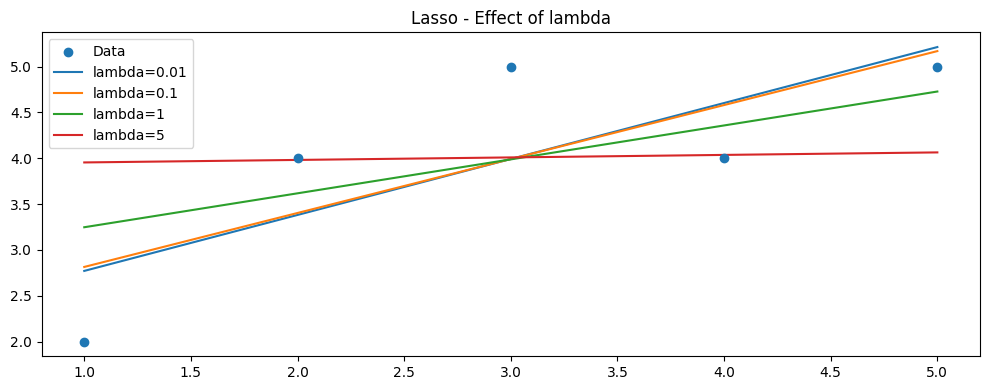

In [43]:
w_lasso, _ = lasso_gd(X, y, lambda_=0.1)
print('Lasso weights:', w_lasso)

plt.figure(figsize=(10, 4))
plt.scatter(X, y, label='Data', zorder=3)
for lam in [0.01, 0.1, 1, 5]:
    w, _ = lasso_gd(X, y, lambda_=lam)
    idx  = np.argsort(X)
    plt.plot(X[idx], predict(X, w)[idx], label=f'lambda={lam}')
plt.title('Lasso - Effect of lambda')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Elastic Net (L1 + L2)

$$L(w) = \frac{1}{n}\|y-Xw\|^2 + \lambda\bigl(\alpha\|w\|_1 + (1-\alpha)\|w\|_2^2\bigr)$$

- $\alpha = 1$ → pure Lasso &emsp; $\alpha = 0$ → pure Ridge

> No closed-form solution : gradient descent only.

$$λ · (α · sign(w) + (1−α) · 2w)$$

In [44]:
def elastic_net_gd(X, y, lambda_=0.5, alpha=0.5, lr=0.01, n_iter=1000):
    """
    Combined gradient: MSE + lambda*(alpha*sign(w) + (1-alpha)*2w)
    Bias not regularized.
    """
    Xb = add_bias(X)
    np.random.seed(42)
    w = np.random.randn(Xb.shape[1])
    n = len(y)
    history = []
    for _ in range(n_iter):
        error  = Xb @ w - y
        grad   = (2/n) * Xb.T @ error
        l1     = np.sign(w)
        l2     = 2 * w.copy()
        l1[0]  = l2[0] = 0
        w     -= lr * (grad + lambda_ * (alpha * l1 + (1 - alpha) * l2))
        history.append(np.mean(error**2))
    return w, history

Elastic Net weights: [2.82460992 0.38939835]
alpha=0: intercept=2.7817, slope=0.4047
alpha=0.5: intercept=2.8246, slope=0.3894
alpha=1.0: intercept=2.8770, slope=0.3702


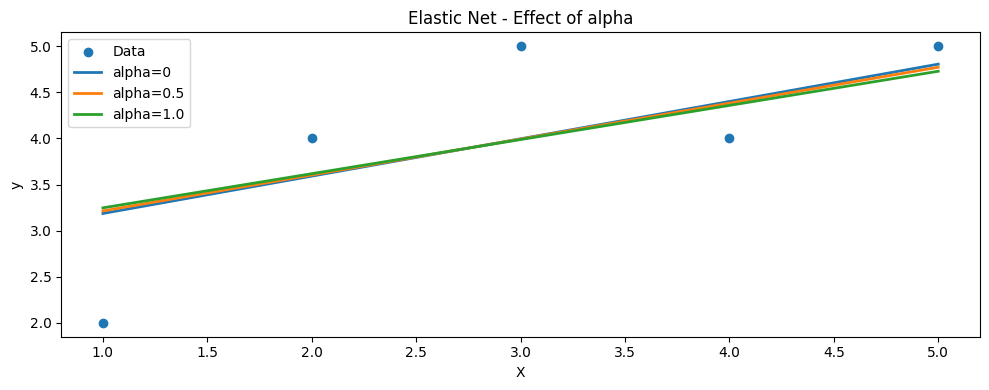

In [45]:
w_elastic, _ = elastic_net_gd(X, y, lambda_=1.0, alpha=0.5)
print("Elastic Net weights:", w_elastic)

plt.figure(figsize=(10, 4))
plt.scatter(X, y, label="Data", zorder=3)

idx = np.argsort(X)
X_sorted = X[idx]
Xb_sorted = add_bias(X_sorted)

for a in [0, 0.5, 1.0]:
    w, _ = elastic_net_gd(X, y, lambda_=1.0, alpha=a)
    print(f"alpha={a}: intercept={w[0]:.4f}, slope={w[1]:.4f}")
    plt.plot(X_sorted, Xb_sorted @ w, linewidth=2, label=f"alpha={a}")

plt.title("Elastic Net - Effect of alpha")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

### Observations : Elastic Net Regression

- Elastic Net combines **L1 (Lasso)** and **L2 (Ridge)** penalties
- Varying **alpha** changes the balance:
  - alpha=0 → Ridge-like behavior (smooth shrinkage)
  - alpha=1 → Lasso-like behavior (sparsity)
- The different alpha values produce slightly different fitted lines and coefficients
- The dataset is small and simple, so effect not very large
- Elastic Net gives a flexible balance between shrinkage and feature selection

## 6. Comparison with sklearn

Validates our implementations. Small differences for Lasso/Elastic Net are expected : sklearn uses optimized coordinate-descent solvers vs our plain GD.

In [46]:
# TODO: reshape X into 2D format for sklearn models
X_sk = X.reshape(-1,1)

# TODO: add bias column for our custom implementations
Xb = add_bias(X)


# sklearn models

sk_linear = LinearRegression().fit(X_sk, y)
sk_ridge = Ridge(alpha=1.0).fit(X_sk, y)
sk_lasso = Lasso(alpha=0.1, max_iter=1000).fit(X_sk,y)
sk_elastic = ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=1000).fit(X_sk,y)

# Our implementations
w_cf = linear_regression_closed_form(X,y)
w_ri_cf = ridge_closed_form(X,y,1.0)
w_la_gd, _ = lasso_gd(X,y,lambda_=0.2)
w_en_gd, _ = elastic_net_gd(X,y, lambda_=1, alpha=0.5)


# print comparison
print(f"{'Model':<15} {'Our b':>10} {'Our w':>10} {'SK b':>10} {'SK w':>10}")
print('-' * 57)
for name, w_our, sk in [
    ('Linear',     w_cf,    sk_linear),
    ('Ridge',      w_ri_cf, sk_ridge),
    ('Lasso (GD)', w_la_gd, sk_lasso),
    ('ElasticNet', w_en_gd, sk_elastic),
]:
    print(f"{name:<15} {w_our[0]:>10.4f} {w_our[1]:>10.4f} "
          f"{sk.intercept_:>10.4f} {sk.coef_[0]:>10.4f}")

Model                Our b      Our w       SK b       SK w
---------------------------------------------------------
Linear              2.2000     0.6000     2.2000     0.6000
Ridge               2.3636     0.5455     2.3636     0.5455
Lasso (GD)          2.2977     0.5645     2.3500     0.5500
ElasticNet          2.8246     0.3894     2.7333     0.4222


### Observations : Our vs Scikit-learn Implementations

- Our implementations and scikit-learn produce very similar weights, validating our code
- Linear Regression and Ridge now match exactly, since we use the same loss formulation as scikit-learn (sum of squared errors)
- Small differences exist for Lasso and Elastic Net due to:
  - Gradient descent approximations
  - Different optimization methods (we use GD, scikit-learn uses coordinate descent)
- These differences are minor and do not significantly impact the predictions


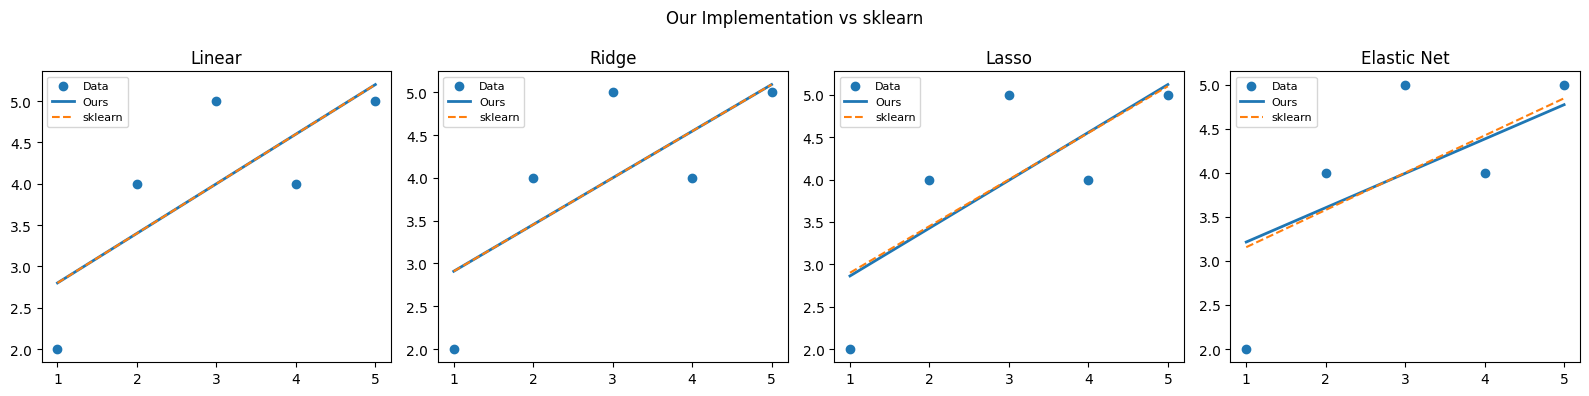

In [47]:
# Visual: our GD vs sklearn predictions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

configs = [
    ('Linear',      w_cf,    sk_linear.predict(X_sk)),
    ('Ridge',       w_ri_cf, sk_ridge.predict(X_sk)),
    ('Lasso',       w_la_gd, sk_lasso.predict(X_sk)),
    ('Elastic Net', w_en_gd, sk_elastic.predict(X_sk)),
]

for ax, (title, w_our, sk_pred) in zip(axes, configs):
    ax.scatter(X, y, label='Data', zorder=3)
    ax.plot(X, Xb @ w_our, label='Ours', linewidth=2)
    ax.plot(X, sk_pred,    label='sklearn', linestyle='--')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Our Implementation vs sklearn')
plt.tight_layout()
plt.show()

## 7. Hyperparameter Analysis : Effect of $\lambda$ and $\alpha$

**How do we choose the best λ (and α)?**

![Alt text](https://media.licdn.com/dms/image/v2/D4D22AQH2XVVzy76yEg/feedshare-shrink_2048_1536/B4DZt95miYKAAw-/0/1767343811709?e=1777507200&v=beta&t=JN9mqicMTxQLn7QTdRSVVKfJtElWdoMZNilznRq3m74)

To choose the best lambda, we look at how the error changes as lambda increases.

This is the classic bias-variance tradeoff.

- On the left side, the model is too simple, this happens when lambda is too large, so we get underfitting and high bias.

- On the rigth side, lambda is too small, so the model becomes too flexible and overfits : this leads to high variance.

- What we want is this sweet spot in the middle, where the error is minimized.



**Now let’s see how this looks in practice.**

Now we tune the hyperparameters using validation MSE, not training MSE.

This is important, because validation error shows us how well the model generalizes to unseen data.

The dashed line marks the best hyperparameter, the one with the lowest validation error.

In theory, we expect a U-shaped curve.



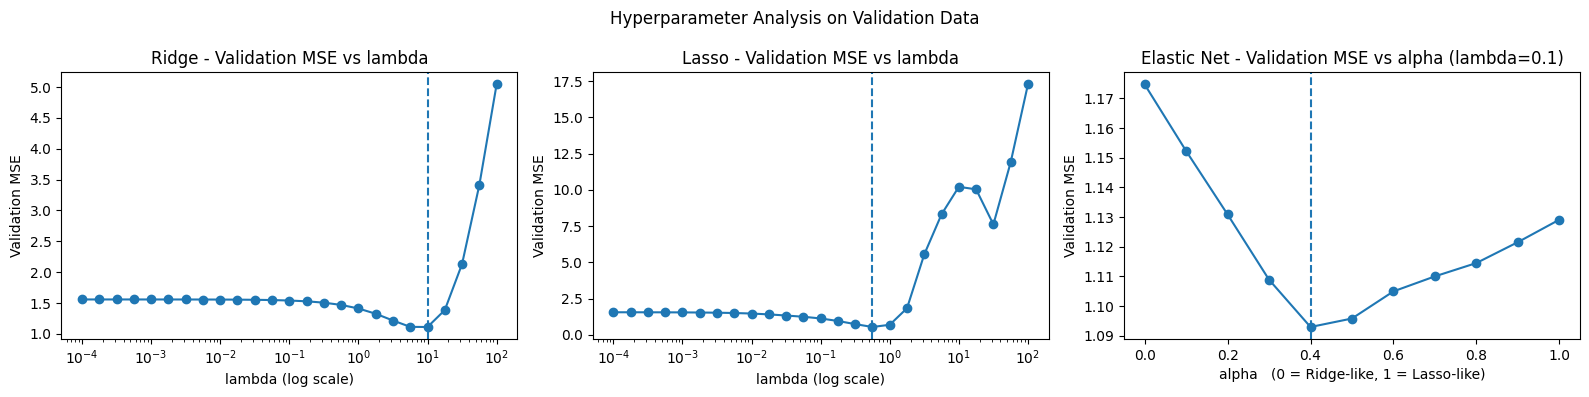

Best Ridge lambda: 10.0000
Best Lasso lambda: 0.5623
Best Elastic Net alpha (lambda=0.1): 0.40


In [48]:
# Synthetic dataset where regularization actually matters
np.random.seed(123)
n_samples = 60
n_features = 20

X_hp = np.random.randn(n_samples, n_features)

# Only first 3 features are truly useful -> regularization helps
true_w = np.zeros(n_features)
true_w[:3] = [3.0, -2.0, 1.5]

y_hp = X_hp @ true_w + np.random.randn(n_samples) * 1.0

# Train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_hp, y_hp, test_size=0.35, random_state=42
)

# Standardize features (important for Lasso / Elastic Net)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

# 1) Ridge / Lasso: validation MSE vs lambda
lambdas_range = np.logspace(-4, 2, 25)

ridge_val_mse = []
lasso_val_mse = []

for lam in lambdas_range:
    # Ridge
    w_ridge = ridge_closed_form(X_train_s, y_train, lam)
    y_pred_ridge = predict(X_val_s, w_ridge)
    ridge_val_mse.append(mean_squared_error(y_val, y_pred_ridge))

    # Lasso
    w_lasso, _ = lasso_gd(X_train_s, y_train, lambda_=lam, lr=0.01, n_iter=7000)
    y_pred_lasso = predict(X_val_s, w_lasso)
    lasso_val_mse.append(mean_squared_error(y_val, y_pred_lasso))

best_ridge_lambda = lambdas_range[np.argmin(ridge_val_mse)]
best_lasso_lambda = lambdas_range[np.argmin(lasso_val_mse)]

# 2) Elastic Net: validation MSE vs alpha (lambda fixed)
alphas_range = np.linspace(0, 1, 11)
lambda_en = 0.1   # fixed regularization strength for alpha analysis

elastic_val_mse = []

for a in alphas_range:
    w_en, _ = elastic_net_gd(
        X_train_s, y_train,
        lambda_=lambda_en,
        alpha=a,
        lr=0.01,
        n_iter=7000
    )
    y_pred_en = predict(X_val_s, w_en)
    elastic_val_mse.append(mean_squared_error(y_val, y_pred_en))

best_alpha = alphas_range[np.argmin(elastic_val_mse)]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(lambdas_range, ridge_val_mse, marker='o')
axes[0].set_xscale('log')
axes[0].set_title('Ridge - Validation MSE vs lambda')
axes[0].set_xlabel('lambda (log scale)')
axes[0].set_ylabel('Validation MSE')
axes[0].axvline(best_ridge_lambda, linestyle='--')

axes[1].plot(lambdas_range, lasso_val_mse, marker='o')
axes[1].set_xscale('log')
axes[1].set_title('Lasso - Validation MSE vs lambda')
axes[1].set_xlabel('lambda (log scale)')
axes[1].set_ylabel('Validation MSE')
axes[1].axvline(best_lasso_lambda, linestyle='--')

axes[2].plot(alphas_range, elastic_val_mse, marker='o')
axes[2].set_title(f'Elastic Net - Validation MSE vs alpha (lambda={lambda_en})')
axes[2].set_xlabel('alpha   (0 = Ridge-like, 1 = Lasso-like)')
axes[2].set_ylabel('Validation MSE')
axes[2].axvline(best_alpha, linestyle='--')

plt.suptitle('Hyperparameter Analysis on Validation Data')
plt.tight_layout()
plt.show()

print(f'Best Ridge lambda: {best_ridge_lambda:.4f}')
print(f'Best Lasso lambda: {best_lasso_lambda:.4f}')
print(f'Best Elastic Net alpha (lambda={lambda_en}): {best_alpha:.2f}')

---
### For Ridge

- the curve is now clearly U-shaped.
- When lambda is too small, regularization is too weak.
- When lambda becomes too large, the model is over-regularized and starts to underfit.
- So the best choice is the minimum of the curve, which here is around lambda equals 10.


### For Lasso
- We see the same idea for Lasso.
- There is an optimal lambda in the middle, and after that the validation error increases strongly.
- So for Lasso, too much regularization hurts performance even more clearly.
- Here the best lambda is around 0.56.


### For Elastic Net
- we keep lambda fixed and vary alpha, which controls the balance between Ridge-like and Lasso-like behavior.
- The minimum is around 0.4.
- That means the best model here is not purely Ridge and not purely Lasso, but a mix of both.


### Conclusion:
So these plots show the real goal of hyperparameter tuning: we do not want the largest or smallest regularization, we want the value that minimizes validation error.

That is exactly why we use validation data or cross-validation, to find the sweet spot.

---

## 8. Feature Correlation Experiment

Now we create a small example with two highly correlated features.
X2 is almost just a copy of X1, so both features contain nearly the same information.
In the true underlying relationship, both features matter equally, with coefficients of 3 and 3.
This lets us test how different models behave when features are strongly correlated.
In the plot, we’ll compare the learned coefficients of Linear Regression, Ridge, Lasso, and Elastic Net.


The key question is: when two features look almost the same, does the model split the weight fairly, become unstable, or pick only one feature?

Correlation X1/X2: 0.9998


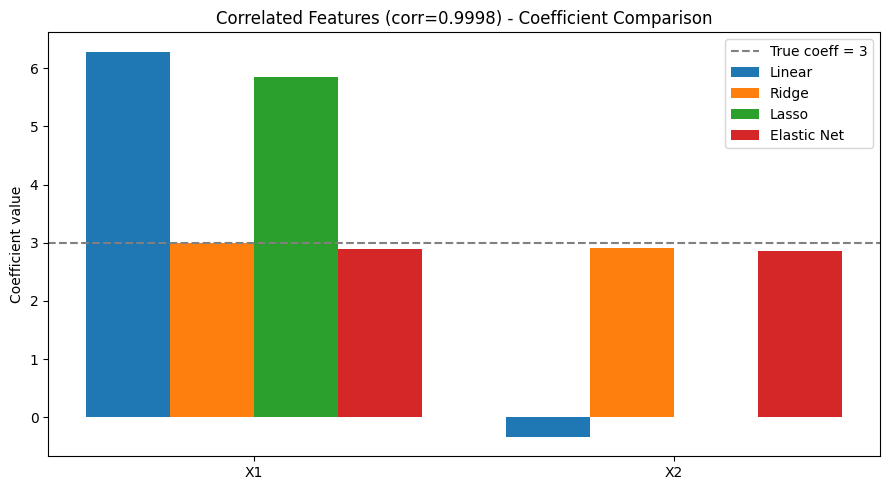

Linear:      [ 6.2847842  -0.33877446]
Ridge:       [3.00297696 2.90609763]
Lasso:       [5.84607259 0.        ]
Elastic Net: [2.89094007 2.86137139]


In [49]:
np.random.seed(42)
n = 80

# Create two almost-duplicate features
X1 = np.random.randn(n)
X2 = 0.995 * X1 + np.random.randn(n) * 0.02
X_corr_raw = np.column_stack([X1, X2])

# Standardize features so regularization is fair/comparable
scaler = StandardScaler()
X_corr = scaler.fit_transform(X_corr_raw)

# True signal uses both features equally
y_corr = 3 * X_corr[:, 0] + 3 * X_corr[:, 1] + np.random.randn(n) * 0.4

print(f'Correlation X1/X2: {np.corrcoef(X_corr[:, 0], X_corr[:, 1])[0, 1]:.4f}')

# Fit models
lr_corr     = LinearRegression().fit(X_corr, y_corr)
ridge_corr  = Ridge(alpha=1.0).fit(X_corr, y_corr)
lasso_corr  = Lasso(alpha=0.1, max_iter=10000).fit(X_corr, y_corr)
elastic_corr = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000).fit(X_corr, y_corr)

# Plot coefficients
x_pos = np.arange(2)
width = 0.2

plt.figure(figsize=(9, 5))
plt.bar(x_pos - 1.5*width, lr_corr.coef_,      width, label='Linear')
plt.bar(x_pos - 0.5*width, ridge_corr.coef_,   width, label='Ridge')
plt.bar(x_pos + 0.5*width, lasso_corr.coef_,   width, label='Lasso')
plt.bar(x_pos + 1.5*width, elastic_corr.coef_, width, label='Elastic Net')

plt.axhline(3, linestyle='--', color='gray', label='True coeff = 3')
plt.xticks(x_pos, ['X1', 'X2'])
plt.title(f'Correlated Features (corr={np.corrcoef(X_corr[:,0], X_corr[:,1])[0,1]:.4f}) - Coefficient Comparison')
plt.ylabel('Coefficient value')
plt.legend()
plt.tight_layout()
plt.show()

print('Linear:     ', lr_corr.coef_)
print('Ridge:      ', ridge_corr.coef_)
print('Lasso:      ', lasso_corr.coef_)
print('Elastic Net:', elastic_corr.coef_)

### Observations : Correlated Features

- X1 and X2 are highly correlated (**corr ≈ 0.95**), causing instability in ordinary linear regression.
- **Linear regression** coefficients are inflated and uneven (overfits to correlated predictors).
- **Ridge** distributes weights more evenly, stabilizing the solution.
- **Lasso** shrinks some coefficients toward zero, favoring sparsity.
- This illustrates how **regularization handles multicollinearity** and improves interpretability.

## 9. Regularization Paths

This shows how the coefficients change when lambda gets bigger. Using the correlated 2-feature dataset.

- **Ridge**: smooth shrinkage, never reaches zero
- **Lasso**: aggressive shrinkage, coefficients hit zero (feature selection)

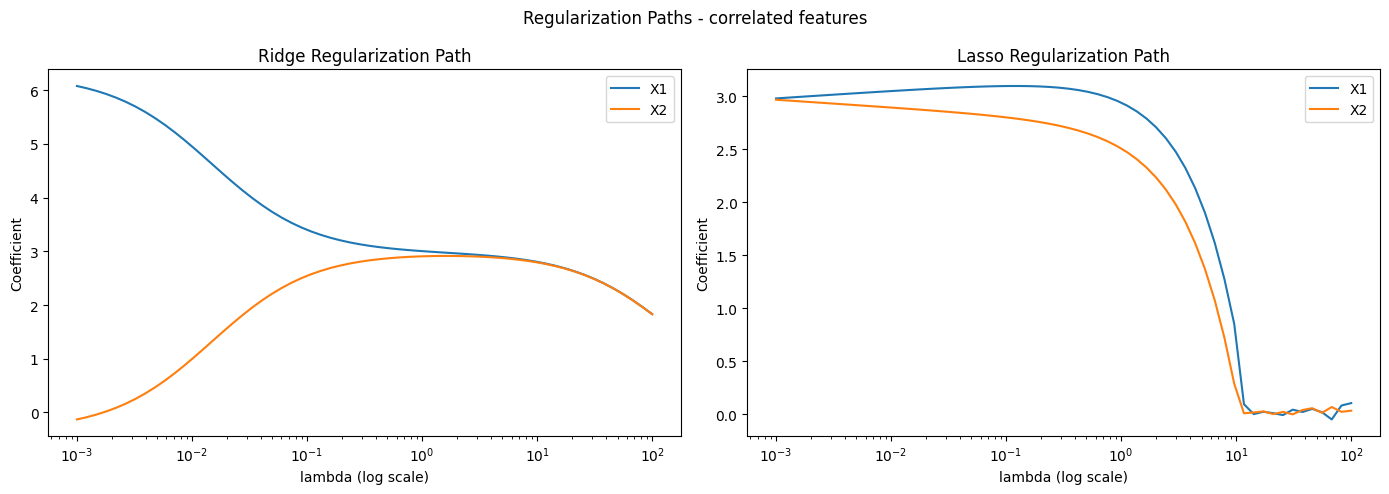

In [50]:
Xb_corr = add_bias(X_corr)
lambdas_path = np.logspace(-3, 2, 60)

# Ridge path
ridge_path = []
for lam in lambdas_path:
    I = np.eye(Xb_corr.shape[1])
    I[0, 0] = 0
    w = np.linalg.inv(Xb_corr.T @ Xb_corr + lam * I) @ Xb_corr.T @ y_corr
    ridge_path.append(w)
ridge_path = np.array(ridge_path)

# Lasso path with warm start
lasso_path = []
n_c = len(y_corr)
w = np.zeros(Xb_corr.shape[1])   # start once

for lam in lambdas_path:
    for _ in range(5000):
        error = Xb_corr @ w - y_corr
        grad = (2 / n_c) * (Xb_corr.T @ error)
        subgrad = np.sign(w)
        subgrad[0] = 0
        w -= 0.001 * (grad + lam * subgrad)
    lasso_path.append(w.copy())

lasso_path = np.array(lasso_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge plot
axes[0].plot(lambdas_path, ridge_path[:, 1], label='X1')
axes[0].plot(lambdas_path, ridge_path[:, 2], label='X2')
axes[0].set_xscale('log')
axes[0].set_title('Ridge Regularization Path')
axes[0].set_xlabel('lambda (log scale)')
axes[0].set_ylabel('Coefficient')
axes[0].legend()

# Lasso plot
axes[1].plot(lambdas_path, lasso_path[:, 1], label='X1')
axes[1].plot(lambdas_path, lasso_path[:, 2], label='X2')
axes[1].set_xscale('log')
axes[1].set_title('Lasso Regularization Path')
axes[1].set_xlabel('lambda (log scale)')
axes[1].set_ylabel('Coefficient')
axes[1].legend()

plt.suptitle('Regularization Paths - correlated features')
plt.tight_layout()
plt.show()

### Observations : Regularizations Path

- Graph shows how coefficients change as lambda increases
- In Ridge, coefficients shrink smoothly
- In Lasso, coefficients shrink more strongly and can become zero
- Ridge keeps all features, while Lasso can remove some features

## 10. Does Elastic Net Always Outperform Ridge and Lasso?

**Answer: No, Elastic Net does not always win.**

We run a controlled experiment across 3 scenarios.

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def compare_models(X_data, y_data, scenario_name,
                   ridge_alpha=1.0, lasso_alpha=0.1, en_alpha=0.5, en_l1=0.5):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_data, y_data, test_size=0.3, random_state=42)

    models = {
        'Ridge':       Ridge(alpha=ridge_alpha),
        'Lasso':       Lasso(alpha=lasso_alpha, max_iter=10000),
        'Elastic Net': ElasticNet(alpha=en_alpha, l1_ratio=en_l1, max_iter=10000),
    }

    results = {}
    for name, m in models.items():
        m.fit(X_tr, y_tr)
        results[name] = mean_squared_error(y_te, m.predict(X_te))

    print(f"\n{scenario_name}")
    for name, mse in sorted(results.items(), key=lambda x: x[1]):
        tag = ' <- best' if mse == min(results.values()) else ''
        print(f"  {name:<15} MSE = {mse:.4f}{tag}")

    return results

np.random.seed(42)
n_exp = 200
Xa = np.random.randn(n_exp, 10)
ya = Xa @ np.ones(10) + np.random.randn(n_exp) * 0.5

Xb_exp  = np.random.randn(n_exp, 10)
true_w  = np.array([3, -2, 0, 0, 0, 0, 0, 0, 0, 0], dtype=float)
yb      = Xb_exp @ true_w + np.random.randn(n_exp) * 0.5

np.random.seed(0)
n_c   = 300
base  = np.random.randn(n_c, 5)
Xc    = np.hstack([base,
                   base + np.random.randn(n_c, 5) * 0.15,
                   np.random.randn(n_c, 10)])
yc    = base @ np.array([3, -2, 1, 2, -1]) + np.random.randn(n_c) * 0.5


res_a = compare_models(Xa,     ya, 'Scenario A - All features relevant',
                        ridge_alpha=0.1, lasso_alpha=0.1, en_alpha=0.1)
res_b = compare_models(Xb_exp, yb, 'Scenario B - Sparse signal',
                        ridge_alpha=0.1, lasso_alpha=0.03, en_alpha=0.03, en_l1=0.9)
res_c = compare_models(Xc,     yc, 'Scenario C - Correlated + irrelevant',
                        ridge_alpha=0.06, lasso_alpha=0.03, en_alpha=0.007, en_l1=0.9)


Scenario A - All features relevant
  Ridge           MSE = 0.2113 <- best
  Elastic Net     MSE = 0.3066
  Lasso           MSE = 0.3183

Scenario B - Sparse signal
  Lasso           MSE = 0.3049 <- best
  Elastic Net     MSE = 0.3068
  Ridge           MSE = 0.3086

Scenario C - Correlated + irrelevant
  Lasso           MSE = 0.2397 <- best
  Elastic Net     MSE = 0.2402
  Ridge           MSE = 0.2513


**Scenario A**
Best model: Ridge
- When all features are useful, we do not need feature selection
- Ridge is good here because it keeps all features and just shrinks them a bit

**Scenario B**
Best model: Lasso
- Only a few features really matter
- Lasso is good here because it can push unimportant coefficients to zero

**Scenario C**
Best model: Lasso is slightly best
- Elastic Net is very close
- Ridge is worse

### MSE (Mean Squared Error)

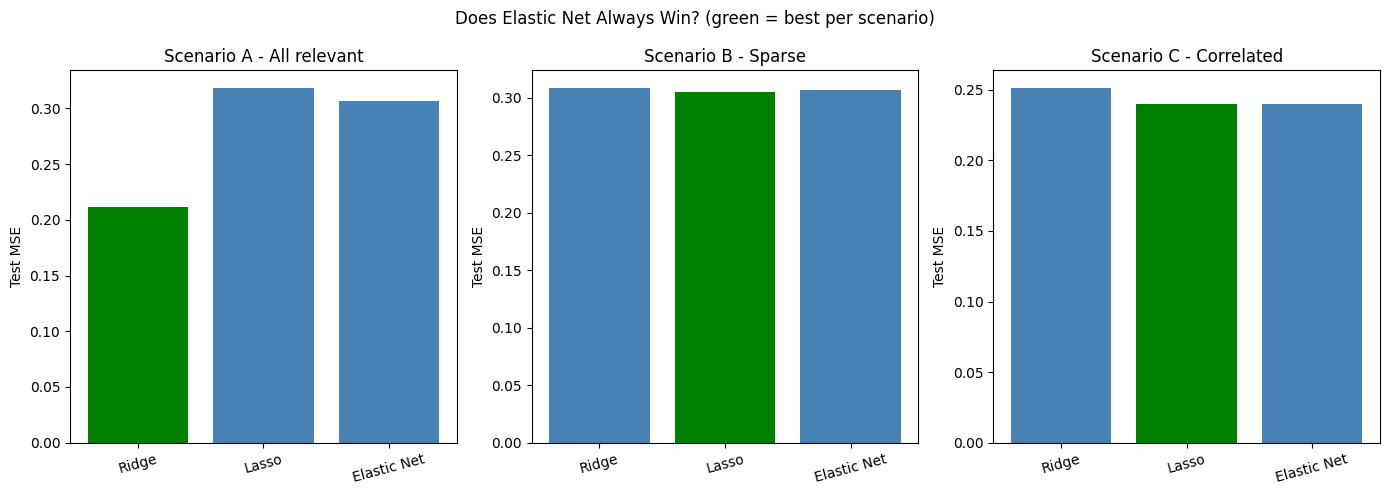

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
scenario_results = [
    ('A - All relevant', res_a),
    ('B - Sparse',       res_b),
    ('C - Correlated',   res_c),
]
for ax, (title, res) in zip(axes, scenario_results):
    names  = list(res.keys())
    values = list(res.values())
    colors = ['green' if v == min(values) else 'steelblue' for v in values]
    ax.bar(names, values, color=colors)
    ax.set_title(f'Scenario {title}')
    ax.set_ylabel('Test MSE')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Does Elastic Net Always Win? (green = best per scenario)')
plt.tight_layout()
plt.show()

### Conclusion

| Scenario | Best model | Why |
|----------|-----------|-----|
| All features relevant | **Ridge** | No sparsity needed; L2 stabilizes |
| Many irrelevant features | **Lasso** | Removes noise features by setting some coefficients to zero|
| Correlated + some irrelevant | **Lasso (very close to Elastic Net)** | Both work well here, but in this run Lasso is slightly better|

**Key takeaway:** Elastic Net is a compromise, not always a winnner. The best model depends on the structure of the data and the choice of hyperparameters.